In [ ]:
!pip install langgraph langchain numpy pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.2/440.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 24.4 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.66
    Uninstalling langchain-core-0.3.66:
      Successfully uninstalled langchain-core-0.3.66


In [ ]:
!pip install langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.8/130.8 kB 3.3 MB/s eta 0:00:00


In [ ]:
!pip install langchain_tavily

In [ ]:
from google.colab import userdata

In [ ]:
import os

os.environ["GROQ_API_KEY"] = userdata.get('groq_api_key')
os.environ["TAVILY_API_KEY"] = userdata.get('tavily_api_key')

In [ ]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(max_results=3)
web_search_results = web_search.invoke("who is the mayor of NYC?")

print(web_search_results["results"][0]["content"])

Mayor Eric Adams has served the people of New York City as an NYPD officer, State Senator, Brooklyn Borough President, and now as the 110th Mayor of the City of New York. Mayor Eric Adams has served the people of New York City as an NYPD officer, State Senator, Brooklyn Borough President, and now as the 110th Mayor of the City of New York. In Albany, Eric built winning coalitions to advance New York City’s values and goals, helping to push through measures to protect tenants and workers, combat gun violence, end the NYPD’s abuses of stop and frisk, and advance human rights — including marriage equality. NYC is a trademark and service mark of the City of New York.


In [ ]:
web_search_results

{'query': 'who is the mayor of NYC?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': "Office of the Mayor | Mayor's Bio | City of New York - NYC.gov",
   'url': 'https://www.nyc.gov/office-of-the-mayor/bio.page',
   'content': 'Mayor Eric Adams has served the people of New York City as an NYPD officer, State Senator, Brooklyn Borough President, and now as the 110th Mayor of the City of New York. Mayor Eric Adams has served the people of New York City as an NYPD officer, State Senator, Brooklyn Borough President, and now as the 110th Mayor of the City of New York. In Albany, Eric built winning coalitions to advance New York City’s values and goals, helping to push through measures to protect tenants and workers, combat gun violence, end the NYPD’s abuses of stop and frisk, and advance human rights — including marriage equality. NYC is a trademark and service mark of the City of New York.',
   'score': 0.8622012,
   'raw_content': None},
  {'title': 

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model = 'llama3-8b-8192'
)

In [ ]:
llm.invoke('What is Gemini')

AIMessage(content='Gemini is a term that can refer to several things.\n\n**In Astrology:**\nIn astrology, Gemini is the third sign of the zodiac, associated with the period from May 21 to June 20. People born during this period are considered Geminis, and are said to possess certain traits such as curiosity, adaptability, and communicative skills.\n\n**In Space Exploration:**\nGemini was a NASA space program that operated from 1961 to 1966. The Gemini program was designed to develop the skills and technologies needed for future manned space flights, including the ability to perform spacewalks, dock with other spacecraft, and conduct long-duration missions. The program included 10 manned flights, with the final mission being Gemini 12 in November 1966.\n\n**In Computing:**\nGemini is also the name of a computer programming language and a web browser. Gemini is a minimalist web browser that was created to provide a simple, text-based alternative to other browsers. The Gemini programming 

In [ ]:
# SuperVisore Agent

In [ ]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model=llm,
    tools=[web_search],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent",
)

In [ ]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [ ]:


for chunk in research_agent.stream({"messages": [{"role": "user", "content": "who is the mayor of NYC?"}]}):
  pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: research_agent
Tool Calls:
  tavily_search (c4d2rtczt)
 Call ID: c4d2rtczt
  Args:
    query: Who is the mayor of New York City?
    search_depth: advanced
    topic: general


Update from node tools:


================================= Tool Message =================================
Name: tavily_search

{"query": "Who is the mayor of New York City?", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/Mayor_of_New_York_City", "title": "Mayor of New York City - Wikipedia", "content": "The current mayor is Eric Adams, who was elected on November 2, 2021, and took office shortly after midnight on January 1, 2022. [...] | Mayor of the City of New York |\n| --- |\n| Image 4.svg) Seal of the City of New York |\n| Image 5 Standard of the mayor of New York City |\n| Image 6_(cropped).jpg) Incumbent Eric Adams since January 1,

In [ ]:
def add(a: float, b: float):
    """Add two numbers."""
    return a + b


def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b


def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b


math_agent = create_react_agent(
    model=llm,
    tools=[add, multiply, divide],
    prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent",
)

In [ ]:
!pip install langgraph-supervisor

In [ ]:
from langgraph_supervisor import create_supervisor


supervisor = create_supervisor(
    model=llm,
    agents=[research_agent, math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

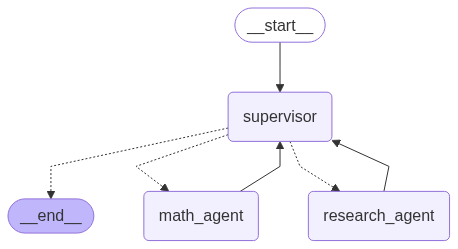

In [ ]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

In [ ]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent


Update from node research_agent:


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


Update from node supervisor:


================================== Ai Message ==================================
Name: supervisor

I've received the result and can now respond directly.

As of 2024, New York state's GDP represents approximately 7.14% of the total US GDP.




In [ ]:
res = supervisor.invoke({
        "messages": [
            {
                "role": "user",
                "content": "what is 2+3",
            }
        ]
    })

In [ ]:
print(res['messages'][-1].content)

5


# SQL AGENT

In [ ]:
import requests

url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"

response = requests.get(url)

if response.status_code == 200:
    # Open a local file in binary write mode
    with open("Chinook.db", "wb") as file:
        # Write the content of the response (the file) to the local file
        file.write(response.content)
    print("File downloaded and saved as Chinook.db")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

File downloaded and saved as Chinook.db


In [ ]:
from langchain.agents.agent_toolkits import SQLDatabaseToolkit
from langchain.sql_database import SQLDatabase
from langchain.llms.openai import OpenAI
from langchain.agents import AgentExecutor

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

print(f"Dialect: {db.dialect}")
print(f"Available tables: {db.get_usable_table_names()}")
print(f'Sample output: {db.run("SELECT * FROM Artist LIMIT 5;")}')

Dialect: sqlite
Available tables: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']
Sample output: [(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains')]


In [ ]:
toolkit = SQLDatabaseToolkit(db=db, llm=llm)

tools = toolkit.get_tools()

for tool in tools:
    print(f"{tool.name}: {tool.description}\n")

sql_db_query: Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.

sql_db_schema: Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3

sql_db_list_tables: Input is an empty string, output is a comma-separated list of tables in the database.

sql_db_query_checker: Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with sql_db_query!



In [ ]:
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7bce27b18550>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7bce27b18550>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7bce27b18550>),
 QuerySQLCheckerTool(description='Use this tool to double check

In [ ]:
from langgraph.prebuilt import create_react_agent

system_prompt = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

You MUST double check your query before executing it. If you get an error while
executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the
database.

To start you should ALWAYS look at the tables in the database to see what you
can query. Do NOT skip this step.

Then you should query the schema of the most relevant tables.
""".format(
    dialect=db.dialect,
    top_k=5,
)

agent = create_react_agent(
    llm,
    tools,
    prompt=system_prompt,
)

In [ ]:
question = "Tell me about all the table present in the database"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Tell me about all the table present in the database
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (xq7dyz4vq)
 Call ID: xq7dyz4vq
  Args:
    tool_input:
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track
================================== Ai Message ==================================

The database contains the following tables: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track.


In [ ]:
example_query = "Which country's customers spent the most?"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Which country's customers spent the most?
================================== Ai Message ==================================
Tool Calls:
  sql_db_query (mxgp4h8mt)
 Call ID: mxgp4h8mt
  Args:
    query: SELECT country, SUM(amount) AS total_spent FROM orders GROUP BY country ORDER BY total_spent DESC LIMIT 1
================================= Tool Message =================================
Name: sql_db_query

Error: (sqlite3.OperationalError) no such table: orders
[SQL: SELECT country, SUM(amount) AS total_spent FROM orders GROUP BY country ORDER BY total_spent DESC LIMIT 1]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (v32zt6rwq)
 Call ID: v32zt6rwq
  Args:
    table_names:
================================= Tool Message =================================
Name: sql_db_schema

Error: table